# INSTALL DEPENDENCIES

In [1]:
!pip -q install \
sentence-transformers \
faiss-cpu \
rank-bm25 \
transformers \
torch \
scikit-learn \
pandas \
numpy \
pyarrow \
tqdm \
matplotlib \
seaborn \
plotly \
sqlalchemy \
sqlite-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 78.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.7 MB/s eta 0:00:00


In [2]:
import os
import re
import gc
import json
import math
import time
import random
import sqlite3
import warnings
import numpy as np
import pandas as pd

from tqdm import tqdm

# ML / NLP
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel

# Retrieval
import faiss
from rank_bm25 import BM25Okapi

# Preprocessing
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [3]:
print("Torch:", torch.__version__)
print("FAISS OK")
print("SentenceTransformers OK")

Torch: 2.10.0+cu128
FAISS OK
SentenceTransformers OK


# GLOBAL CONFIG

In [4]:
RANDOM_SEED = 42

# Embedding model from your architecture
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

# Retrieval settings
TOP_K_FAISS = 20
TOP_K_BM25 = 20
TOP_K_RERANK = 5

# Batch processing
BATCH_SIZE = 64

# FAISS similarity metric
FAISS_METRIC = "cosine"

# Logging
LOG_DB_PATH = "/kaggle/working/retrieval_logs.db"

# Export paths
EXPORT_DIR = "/kaggle/working/exports"

os.makedirs(EXPORT_DIR, exist_ok=True)

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [7]:
embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    device=DEVICE
)

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [8]:
conn = sqlite3.connect(LOG_DB_PATH)

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS retrieval_logs (
    run_id TEXT,
    query_text TEXT,
    retrieved_ids TEXT,
    similarity_scores TEXT,
    rerank_scores TEXT,
    latency_ms REAL,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

print("SQLite logging initialized.")

SQLite logging initialized.


In [9]:
def memory_usage_mb(df):
    return round(df.memory_usage(deep=True).sum() / 1024**2, 2)

In [10]:
print("Embedding model:", EMBEDDING_MODEL_NAME)
print("Top-K FAISS:", TOP_K_FAISS)
print("Top-K BM25:", TOP_K_BM25)
print("Top-K Rerank:", TOP_K_RERANK)
print("Device:", DEVICE)

Embedding model: paraphrase-multilingual-MiniLM-L12-v2
Top-K FAISS: 20
Top-K BM25: 20
Top-K Rerank: 5
Device: cuda


# Load Dataset

In [11]:
DATASET_PATH = "/kaggle/input/datasets/mouadelbaz/gold-tabels/parquet_exports/gold_ticket_similarity.parquet"

df = pd.read_parquet(DATASET_PATH)

print("Shape:", df.shape)
df.head()

Shape: (230114, 29)


,similarity_pk,ticket_pk,source_system,ticket_id,created_at,closed_at,text_corpus,synthetic_text_corpus,similarity_method,embedding_strategy,...,avg_followup_content_length,private_followup_ratio,url_content_ratio,meaningful_content_ratio,has_os_context,has_hardware_context,has_bios_context,has_software_context,similar_ticket_ids,similarity_scores
0,4ceef0c770bdc93599fb1d7131032c69,2013_2,GLPI,2,2013-05-13 17:27:43,2013-05-16 12:29:40,None,prio_high urg_critical impact_medium ticket_un...,synthetic_context,structured_metadata,...,271.00,0.0,0.0,1.0,0,0,0,0,None,None
1,6cc7ce0f8b7df1ecd0560860283acf40,2013_3,GLPI,3,2013-05-14 17:38:55,2013-06-30 10:55:47,None,prio_medium urg_medium impact_medium ticket_un...,synthetic_context,structured_metadata,...,127.00,0.0,0.0,1.0,0,0,0,0,None,None
2,23142610733bcac6466bce80d180c346,2013_4,GLPI,4,2013-05-15 13:01:00,2013-07-01 19:46:26,None,prio_medium urg_medium impact_medium ticket_un...,synthetic_context,structured_metadata,...,130.38,0.0,0.0,1.0,0,0,0,0,None,None
3,10ac3171da0e097808f00c3ad5fb994d,2013_5,GLPI,5,2013-05-15 13:21:00,2013-06-20 19:25:32,None,prio_critical urg_critical impact_high ticket_...,synthetic_context,structured_metadata,...,258.00,0.0,0.0,1.0,0,0,0,0,None,None
4,49e2a88ee2717c5a044429d4da872925,2013_6,GLPI,6,2013-05-15 14:44:54,2013-06-30 10:55:47,None,prio_medium urg_medium impact_medium ticket_un...,synthetic_context,structured_metadata,...,0.00,0.0,0.0,0.0,0,0,0,0,None,None


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230114 entries, 0 to 230113
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   similarity_pk                230114 non-null  object 
 1   ticket_pk                    230114 non-null  object 
 2   source_system                230114 non-null  object 
 3   ticket_id                    230114 non-null  object 
 4   created_at                   201527 non-null  object 
 5   closed_at                    200911 non-null  object 
 6   text_corpus                  228587 non-null  object 
 7   synthetic_text_corpus        1527 non-null    object 
 8   similarity_method            230114 non-null  object 
 9   embedding_strategy           230114 non-null  object 
 10  text_source_type             230114 non-null  object 
 11  embedding_model              228587 non-null  object 
 12  priority_encoded             1527 non-null    float64
 13 

In [13]:
df.columns.tolist()

['similarity_pk',
 'ticket_pk',
 'source_system',
 'ticket_id',
 'created_at',
 'closed_at',
 'text_corpus',
 'synthetic_text_corpus',
 'similarity_method',
 'embedding_strategy',
 'text_source_type',
 'embedding_model',
 'priority_encoded',
 'urgency_encoded',
 'impact_encoded',
 'followup_count_bucket',
 'corpus_quality_score',
 'similarity_confidence',
 'followup_count',
 'avg_followup_content_length',
 'private_followup_ratio',
 'url_content_ratio',
 'meaningful_content_ratio',
 'has_os_context',
 'has_hardware_context',
 'has_bios_context',
 'has_software_context',
 'similar_ticket_ids',
 'similarity_scores']

In [14]:
important_cols = [
    "source_system",
    "text_source_type",
    "similarity_method",
    "text_corpus",
    "synthetic_text_corpus",
    "corpus_quality_score",
    "similarity_confidence"
]

df[important_cols].head(5)

,source_system,text_source_type,similarity_method,text_corpus,synthetic_text_corpus,corpus_quality_score,similarity_confidence
0,GLPI,synthetic_context,synthetic_context,None,prio_high urg_critical impact_medium ticket_un...,0.3,0.25
1,GLPI,synthetic_context,synthetic_context,None,prio_medium urg_medium impact_medium ticket_un...,0.3,0.25
2,GLPI,synthetic_context,synthetic_context,None,prio_medium urg_medium impact_medium ticket_un...,0.5,0.45
3,GLPI,synthetic_context,synthetic_context,None,prio_critical urg_critical impact_high ticket_...,0.3,0.25
4,GLPI,synthetic_context,synthetic_context,None,prio_medium urg_medium impact_medium ticket_un...,0.3,0.25


In [15]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 230,114
Columns: 29


In [16]:
memory_mb = round(df.memory_usage(deep=True).sum() / 1024**2, 2)

print(f"Memory Usage: {memory_mb} MB")

Memory Usage: 237.02 MB


In [17]:
source_counts = df["source_system"].value_counts()

print(source_counts)

source_system
customer_support_tickets_200k    200000
dataset_tickets_multi_lang        28587
GLPI                               1527
Name: count, dtype: int64


In [18]:
df["text_source_type"].value_counts()

text_source_type
real_text            228587
synthetic_context      1527
Name: count, dtype: int64

In [19]:
df["similarity_method"].value_counts()

similarity_method
nlp_embedding        228587
synthetic_context      1527
Name: count, dtype: int64

In [20]:
nulls = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

nulls.columns = ["column", "null_count"]

nulls["null_percent"] = (
    nulls["null_count"] / len(df) * 100
).round(2)

nulls.head(20)

,column,null_count,null_percent
0,similarity_scores,230114,100.00
1,similar_ticket_ids,230114,100.00
2,urgency_encoded,228587,99.34
3,priority_encoded,228587,99.34
4,synthetic_text_corpus,228587,99.34
5,impact_encoded,228587,99.34
6,followup_count_bucket,228587,99.34
7,closed_at,29203,12.69
8,created_at,28587,12.42
9,embedding_model,1527,0.66


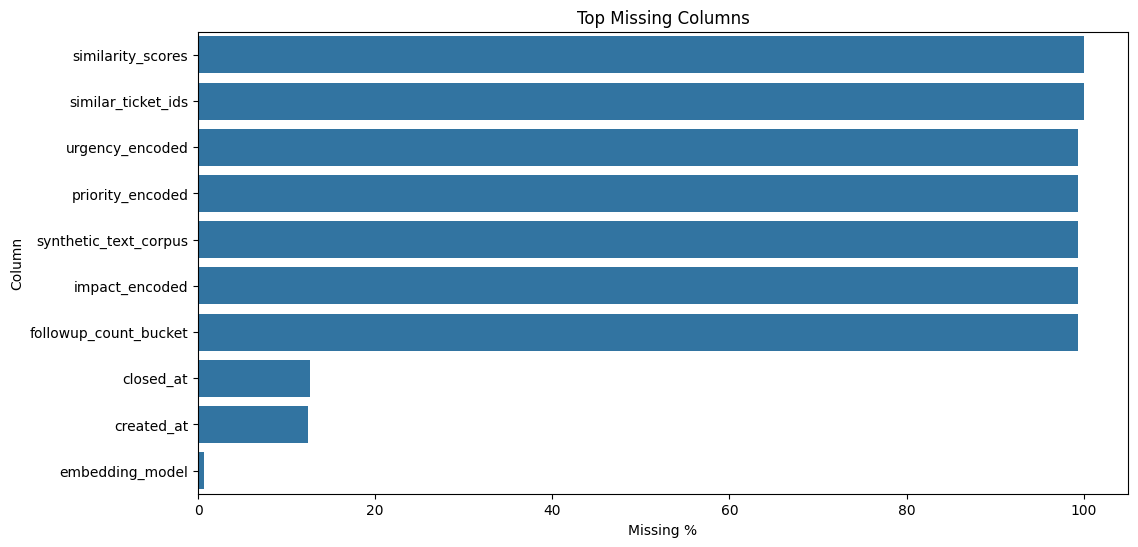

In [21]:
top_nulls = nulls.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_nulls,
    x="null_percent",
    y="column"
)

plt.title("Top Missing Columns")
plt.xlabel("Missing %")
plt.ylabel("Column")

plt.show()

In [22]:
duplicates = df.duplicated(subset=["ticket_pk"]).sum()

print("Duplicate ticket_pk:", duplicates)

Duplicate ticket_pk: 0


In [23]:
df["text_length"] = (
    df["text_corpus"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["text_length"].describe()

count    230114.000000
mean        168.484473
std         121.733444
min           0.000000
25%         113.000000
50%         137.000000
75%         149.000000
max        1526.000000
Name: text_length, dtype: float64

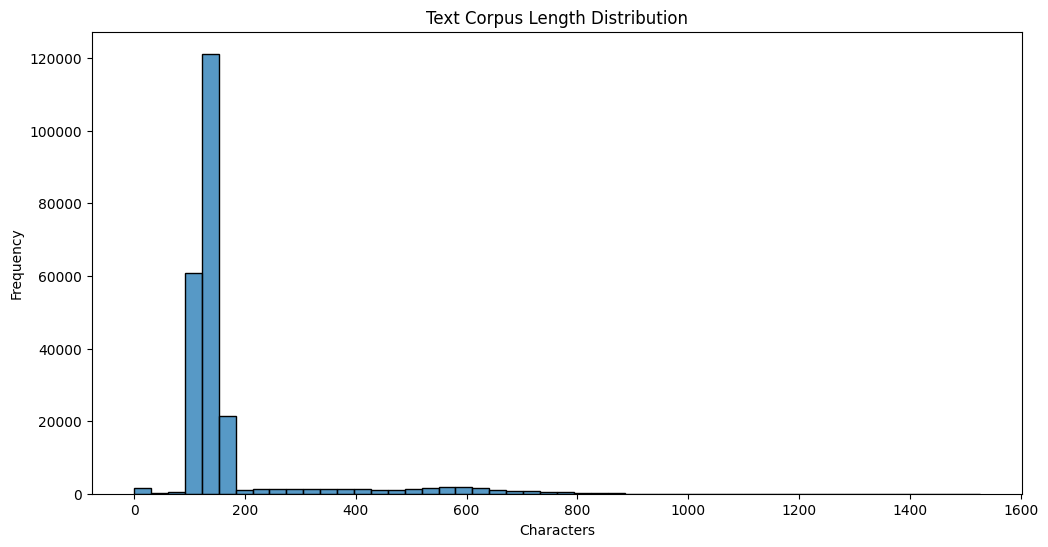

In [24]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["text_length"],
    bins=50
)

plt.title("Text Corpus Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [25]:
df["corpus_quality_score"].describe()

count    230114.000000
mean          0.995965
std           0.051196
min           0.300000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: corpus_quality_score, dtype: float64

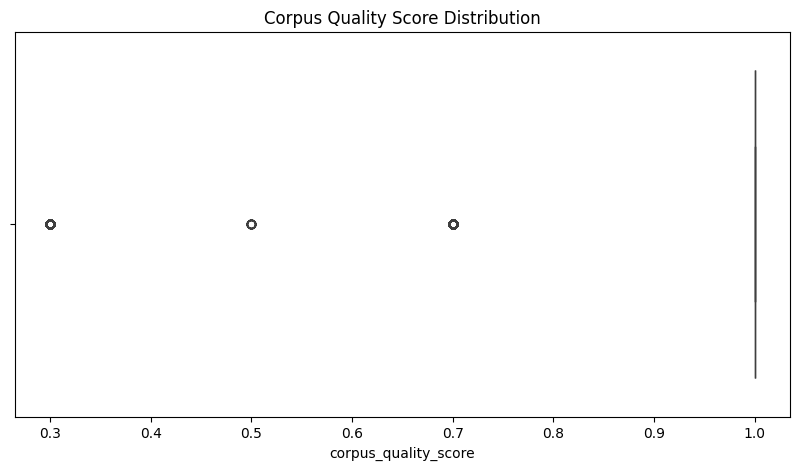

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["corpus_quality_score"]
)

plt.title("Corpus Quality Score Distribution")

plt.show()

In [27]:
df["similarity_confidence"].describe()

count    230114.000000
mean          0.896297
std           0.047293
min           0.250000
25%           0.900000
50%           0.900000
75%           0.900000
max           0.900000
Name: similarity_confidence, dtype: float64

In [28]:
empty_text = (
    df["text_corpus"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty text corpus rows:", empty_text)

Empty text corpus rows: 1527


In [29]:
synthetic_empty = (
    df["synthetic_text_corpus"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty synthetic corpus rows:", synthetic_empty)

Empty synthetic corpus rows: 228587


In [30]:
print("="*50)
print("DATASET HEALTH SUMMARY")
print("="*50)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate ticket_pk:", duplicates)
print("Empty text corpus:", empty_text)
print("Empty synthetic corpus:", synthetic_empty)

print("\nSource systems:")
print(df["source_system"].value_counts())

print("\nSimilarity methods:")
print(df["similarity_method"].value_counts())

DATASET HEALTH SUMMARY
Rows: 230114
Columns: 30
Duplicate ticket_pk: 0
Empty text corpus: 1527
Empty synthetic corpus: 228587

Source systems:
source_system
customer_support_tickets_200k    200000
dataset_tickets_multi_lang        28587
GLPI                               1527
Name: count, dtype: int64

Similarity methods:
similarity_method
nlp_embedding        228587
synthetic_context      1527
Name: count, dtype: int64


# Data Cleaning + Corpus Preparation

In [57]:
work_df = df.copy()

print("Working dataframe created.")

Working dataframe created.


In [58]:
work_df["retrieval_text"] = np.where(
    work_df["text_source_type"] == "real_text",
    work_df["text_corpus"],
    work_df["synthetic_text_corpus"]
)

In [59]:
work_df[
    [
        "source_system",
        "text_source_type",
        "retrieval_text"
    ]
].head()

,source_system,text_source_type,retrieval_text
0,GLPI,synthetic_context,prio_high urg_critical impact_medium ticket_un...
1,GLPI,synthetic_context,prio_medium urg_medium impact_medium ticket_un...
2,GLPI,synthetic_context,prio_medium urg_medium impact_medium ticket_un...
3,GLPI,synthetic_context,prio_critical urg_critical impact_high ticket_...
4,GLPI,synthetic_context,prio_medium urg_medium impact_medium ticket_un...


In [95]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # lowercase
    text = text.lower()

    # remove html
    text = re.sub(r"<.*?>", " ", text)

    # remove urls
    text = re.sub(r"http\\S+|www\\S+", " ", text)

    # remove emails
    text = re.sub(r"\\S+@\\S+", " ", text)

    # normalize newlines/tabs
    text = re.sub(r"[\\n\\r\\t]+", " ", text)

    # remove repeated spaces
    text = re.sub(r"\\s+", " ", text)

    # remove repeated punctuation
    text = re.sub(r"([.!?])\\1+", r"\\1", text)

    # trim
    text = text.strip()

    return text

In [96]:
tqdm.pandas()

work_df["retrieval_text_clean"] = (
    work_df["retrieval_text"]
    .progress_apply(clean_text)
)

100%|██████████| 230086/230086 [00:04<00:00, 55690.98it/s]


In [97]:
before_rows = len(work_df)

work_df = work_df[
    work_df["retrieval_text_clean"].str.strip() != ""
]

after_rows = len(work_df)

print("Removed rows:", before_rows - after_rows)
print("Remaining rows:", after_rows)

Removed rows: 0
Remaining rows: 230086


In [98]:
work_df["text_char_length"] = (
    work_df["retrieval_text_clean"]
    .str.len()
)

work_df["text_word_length"] = (
    work_df["retrieval_text_clean"]
    .str.split()
    .apply(len)
)

In [99]:
work_df[
    [
        "text_char_length",
        "text_word_length"
    ]
].describe()

,text_char_length,text_word_length
count,230086.000000,230086.000000
mean,165.444034,44.955247
std,118.492696,32.619918
min,31.000000,7.000000
25%,110.000000,32.000000
50%,134.000000,38.000000
75%,149.000000,40.000000
max,1481.000000,398.000000


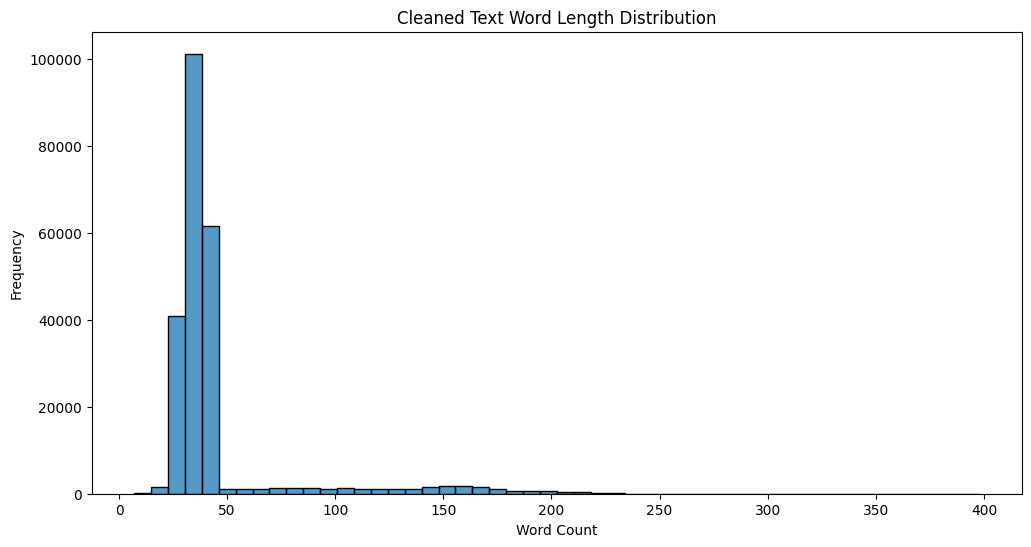

In [100]:
plt.figure(figsize=(12,6))

sns.histplot(
    work_df["text_word_length"],
    bins=50
)

plt.title("Cleaned Text Word Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

In [101]:
MIN_WORDS = 5

before_filter = len(work_df)

work_df = work_df[
    work_df["text_word_length"] >= MIN_WORDS
]

after_filter = len(work_df)

print("Removed short tickets:", before_filter - after_filter)

Removed short tickets: 0


In [102]:
before_dup = len(work_df)

work_df = work_df.drop_duplicates(
    subset=["ticket_pk"]
)

after_dup = len(work_df)

print("Removed duplicates:", before_dup - after_dup)

Removed duplicates: 0


In [103]:
work_df["retrieval_text_clean"].isna().sum()

np.int64(0)

In [104]:
work_df["text_source_type"].value_counts()

text_source_type
real_text            228559
synthetic_context      1527
Name: count, dtype: int64

In [105]:
work_df[
    [
        "source_system",
        "retrieval_text_clean"
    ]
].head(10)

,source_system,retrieval_text_clean
0,GLPI,p io_high u g_c i ical impac _medium icke _u ...
1,GLPI,p io_medium u g_medium impac _medium icke _u ...
2,GLPI,p io_medium u g_medium impac _medium icke _u ...
3,GLPI,p io_c i ical u g_c i ical impac _high icke _...
4,GLPI,p io_medium u g_medium impac _medium icke _u ...
5,GLPI,p io_c i ical u g_c i ical impac _high icke _...
6,GLPI,p io_c i ical u g_c i ical impac _c i ical ic...
7,GLPI,p io_medium u g_medium impac _medium icke _u ...
8,GLPI,p io_high u g_high impac _medium icke _u k ow...
9,GLPI,p io_medium u g_medium impac _medium icke _u ...


In [106]:
retrieval_df = work_df[
    [
        "similarity_pk",
        "ticket_pk",
        "source_system",
        "text_source_type",
        "similarity_method",
        "retrieval_text_clean",
        "corpus_quality_score",
        "similarity_confidence",
        "priority_encoded",
        "urgency_encoded",
        "impact_encoded"
    ]
].reset_index(drop=True)

In [107]:
print("="*50)
print("FINAL RETRIEVAL DATASET")
print("="*50)

print("Rows:", len(retrieval_df))
print("Columns:", len(retrieval_df.columns))

print("\nSource Systems:")
print(retrieval_df["source_system"].value_counts())

print("\nText Types:")
print(retrieval_df["text_source_type"].value_counts())

FINAL RETRIEVAL DATASET
Rows: 230086
Columns: 11

Source Systems:
source_system
customer_support_tickets_200k    200000
dataset_tickets_multi_lang        28559
GLPI                               1527
Name: count, dtype: int64

Text Types:
text_source_type
real_text            228559
synthetic_context      1527
Name: count, dtype: int64


In [108]:
newline_count = (
    work_df["retrieval_text"]
    .astype(str)
    .str.contains(r"\\n")
    .sum()
)

print("Rows containing newline characters:", newline_count)

Rows containing newline characters: 1233


In [109]:
newline_examples = work_df[
    work_df["retrieval_text"]
    .astype(str)
    .str.contains(r"\\n")
][["retrieval_text"]].head(5)

for i, row in enumerate(newline_examples["retrieval_text"]):
    print(f"\n========== EXAMPLE {i+1} ==========\n")
    print(row[:2000])


========== EXAMPLE 1 ==========

Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\n\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.

========== EXAMPLE 2 ==========

Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which

In [110]:
def has_repeated_patterns(text):

    if pd.isna(text):
        return False

    text = str(text).lower()

    # repeated 2-5 word patterns
    pattern = r'(\b(?:\w+\s+){1,5}\w+\b)(?:\s+\1\b)+'

    return bool(re.search(pattern, text))

repeated_pattern_count = (
    work_df["retrieval_text"]
    .apply(has_repeated_patterns)
    .sum()
)

print("Rows with repeated phrase patterns:", repeated_pattern_count)

Rows with repeated phrase patterns: 115


In [111]:
bad_examples = work_df[
    work_df["retrieval_text"]
    .apply(has_repeated_patterns)
][["retrieval_text"]].head(10)

for i, row in enumerate(bad_examples["retrieval_text"]):
    print(f"\n========== BAD EXAMPLE {i+1} ==========\n")
    print(row[:3000])


========== BAD EXAMPLE 1 ==========

Data Security Weakness in Hospital Networks Hospital networks are facing possible data security weaknesses due to obsolete security measures. Despite applying patch updates and running system scans, the problem remains unresolved. Immediate assistance is required to address this issue.

========== BAD EXAMPLE 2 ==========

Sicherheitsvorfall im Krankenhaus Im Krankenhaus kam es zu einem Sicherheitsvorfall, bei dem sensible medizinische Daten durch IT-Systeme kompromittiert wurden. Es besteht der Verdacht auf einen Phishing-Angriff. Vorbeugend wurde ein erster Virenscan durchgeführt. Das betroffene System wurde vorübergehend isoliert, um weiteren Schaden zu vermeiden. Die Angelegenheit wird mit hoher Ernsthaftigkeit behandelt, und eine gründliche Untersuchung zur Bestimmung der Ursache und des Ausmaßes des Vorfalls läuft. Zudem werden die Sicherheitsprotokolle umfassend überprüft, um zukünftigen Vorfällen vorzubeugen. Wir halten Sie über die Entwick

In [112]:
def repetition_ratio(text):

    words = str(text).split()

    if len(words) == 0:
        return 0

    unique_words = len(set(words))

    return 1 - (unique_words / len(words))

work_df["repetition_ratio"] = (
    work_df["retrieval_text"]
    .apply(repetition_ratio)
)

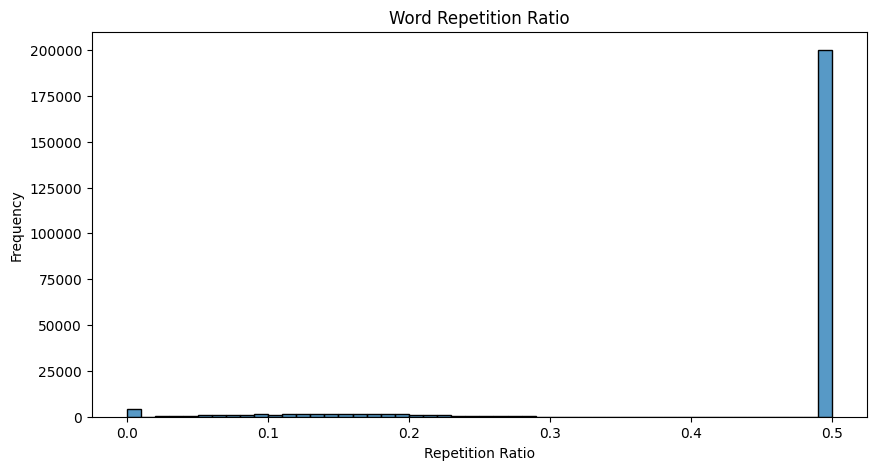

In [113]:
plt.figure(figsize=(10,5))

sns.histplot(
    work_df["repetition_ratio"],
    bins=50
)

plt.title("Word Repetition Ratio")
plt.xlabel("Repetition Ratio")
plt.ylabel("Frequency")

plt.show()

In [114]:
corrupted_rows = work_df[
    work_df["repetition_ratio"] > 0.6
]

print("Highly repetitive rows:", len(corrupted_rows))

Highly repetitive rows: 0


In [115]:
for text in corrupted_rows["retrieval_text"].head(5):
    print("\n====================\n")
    print(text[:3000])

In [116]:
def remove_repeated_phrases(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # remove repeated consecutive phrases
    pattern = r'\b(.+?)(?:\s+\1\b)+'

    text = re.sub(pattern, r'\1', text)

    return text

In [117]:
work_df["retrieval_text_clean"] = (
    work_df["retrieval_text_clean"]
    .apply(remove_repeated_phrases)
)

In [118]:
suspicious = work_df[
    work_df["repetition_ratio"] > 0.75
]

print(len(suspicious))

0


# Dense Embeddings + FAISS Index

In [119]:
# =========================================================
# STEP 1 — SEMANTIC EMBEDDINGS
# =========================================================

semantic_embeddings = embedding_model.encode(
    retrieval_df["retrieval_text_clean"].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

semantic_embeddings = semantic_embeddings.astype("float32")

print("Semantic embedding shape:", semantic_embeddings.shape)

Batches:   0%|          | 0/3596 [00:00<?, ?it/s]

Semantic embedding shape: (230086, 384)


In [120]:
# =========================================================
# STEP 2 — STRUCTURED FEATURES
# =========================================================

structured_features = retrieval_df[
    [
        "priority_encoded",
        "urgency_encoded",
        "impact_encoded"
    ]
].fillna(0)

print(structured_features.head())

   priority_encoded  urgency_encoded  impact_encoded
0               4.0              5.0             3.0
1               3.0              3.0             3.0
2               3.0              3.0             3.0
3               5.0              5.0             4.0
4               3.0              3.0             3.0


In [121]:
# =========================================================
# STEP 3 — NORMALIZE STRUCTURED FEATURES
# =========================================================

structured_features = structured_features / 5.0

structured_features = structured_features.values.astype("float32")

print("Structured feature shape:", structured_features.shape)

Structured feature shape: (230086, 3)


In [122]:
# =========================================================
# STEP 4 — HYBRID VECTOR CONCATENATION
# Final Vector =
# [ sentence_embedding | structured_features ]
# =========================================================

final_embeddings = np.hstack([
    semantic_embeddings,
    structured_features
])

print("Final embedding shape:", final_embeddings.shape)

Final embedding shape: (230086, 387)


In [123]:
# =========================================================
# STEP 5 — FINAL VECTOR NORMALIZATION
# =========================================================

faiss.normalize_L2(final_embeddings)

print("FAISS normalization complete.")

FAISS normalization complete.


In [124]:
# =========================================================
# STEP 6 — BUILD FAISS INDEX
# =========================================================

dimension = final_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(final_embeddings)

print("FAISS index size:", index.ntotal)
print("Vector dimension:", dimension)

FAISS index size: 230086
Vector dimension: 387


In [125]:
# =========================================================
# STEP 7 — SAVE FAISS INDEX
# =========================================================

faiss.write_index(
    index,
    f"{EXPORT_DIR}/ticket_similarity.index"
)

print("FAISS index exported.")

FAISS index exported.


In [126]:
# =========================================================
# STEP 8 — SAVE RETRIEVAL METADATA
# =========================================================

retrieval_df.to_parquet(
    f"{EXPORT_DIR}/retrieval_metadata.parquet",
    index=False
)

print("Retrieval metadata exported.")

Retrieval metadata exported.


# Hybrid Sparse Retrieval (BM25)

In [127]:
# =========================================================
# STEP 1 — TOKENIZATION
# =========================================================

tokenized_corpus = [
    text.split()
    for text in retrieval_df["retrieval_text_clean"]
]

print("Tokenized documents:", len(tokenized_corpus))

Tokenized documents: 230086


In [128]:
# =========================================================
# STEP 2 — BM25 INDEX
# =========================================================

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 index created.")

BM25 index created.


In [129]:
# =========================================================
# STEP 3 — SAVE BM25
# =========================================================

import pickle

with open(
    f"{EXPORT_DIR}/bm25_index.pkl",
    "wb"
) as f:
    pickle.dump(bm25, f)

print("BM25 index exported.")

BM25 index exported.


In [130]:
# =========================================================
# STEP 4 — TEST BM25 SEARCH
# =========================================================

query = "vpn connection timeout after update"

tokenized_query = query.lower().split()

scores = bm25.get_scores(tokenized_query)

top_k = np.argsort(scores)[::-1][:5]

for rank, idx in enumerate(top_k):

    print(f"\n===== RANK {rank+1} =====")
    print("Score:", scores[idx])

    print(
        retrieval_df.iloc[idx]["retrieval_text_clean"][:1000]
    )


===== RANK 1 =====
Score: 0.0
p io_high u g_c i ical impac _medium  icke _u k ow _s a us  esolu io _ove due mode a e_ esolu io

===== RANK 2 =====
Score: 0.0
i qui y abou  p ojec  ma ageme  fea u es looki g fo  de ailed i fo ma io  o   he p ojec  ma ageme  saas fea u es a d cus omiza io  op io s available o  you  pla fo m. specifically, i am i e es ed i  lea i g abou   he va ious  ools a d fu c io ali ies  he pla fo m offe s, as well as  he wo kflow au oma io  a d  epo i g capabili ies. addi io ally, i would like  o k ow abou   he  hi d-pa y app a d se vice i eg a io s.  ha k you fo  you  assis a ce, a d i look fo wa d  o hea i g back soo . please le  me k ow if  he e is a y addi io al i fo ma io  you  eed.

===== RANK 3 =====
Score: 0.0
upda e  eques  fo  saas pla fo m i eg a io  fea u es  eques i g a  upda e o   he i eg a io  fea u es fo  ou  saas pla fo m. we  eed e ha ced compa ibili y wi h shopwa e, quickbooks, a d figma  o imp ove ou  wo kflow. could you please p ovide a  imeli 

# Hybrid Retrieval + Reciproal Rank Fusion (RRF)

In [131]:
# =========================================================
# STEP 1 — FAISS DENSE RETRIEVAL
# =========================================================

def dense_search(
    query,
    top_k=20,
    priority=0,
    urgency=0,
    impact=0
):

    # -----------------------------------------
    # semantic embedding
    # -----------------------------------------

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    # -----------------------------------------
    # structured query vector
    # -----------------------------------------

    structured_query = np.array([
        [
            priority / 5.0,
            urgency / 5.0,
            impact / 5.0
        ]
    ], dtype="float32")

    # -----------------------------------------
    # hybrid vector
    # -----------------------------------------

    final_query_vector = np.hstack([
        query_embedding,
        structured_query
    ])

    # normalize
    faiss.normalize_L2(final_query_vector)

    # -----------------------------------------
    # FAISS search
    # -----------------------------------------

    scores, indices = index.search(
        final_query_vector,
        top_k
    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        results.append({
            "idx": int(idx),
            "score": float(score),
            "method": "dense"
        })

    return results

In [132]:
# =========================================================
# STEP 2 — BM25 SPARSE RETRIEVAL
# =========================================================

def sparse_search(query, top_k=20):

    tokenized_query = query.lower().split()

    scores = bm25.get_scores(tokenized_query)

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []

    for idx in top_indices:

        results.append({
            "idx": int(idx),
            "score": float(scores[idx]),
            "method": "sparse"
        })

    return results

In [133]:
# =========================================================
# STEP 3 — RECIPROCAL RANK FUSION
# =========================================================

def reciprocal_rank_fusion(
    dense_results,
    sparse_results,
    k=60
):

    rrf_scores = {}

    # -----------------------------------------
    # dense rankings
    # -----------------------------------------

    for rank, item in enumerate(dense_results):

        idx = item["idx"]

        rrf_scores[idx] = (
            rrf_scores.get(idx, 0)
            + 1 / (k + rank + 1)
        )

    # -----------------------------------------
    # sparse rankings
    # -----------------------------------------

    for rank, item in enumerate(sparse_results):

        idx = item["idx"]

        rrf_scores[idx] = (
            rrf_scores.get(idx, 0)
            + 1 / (k + rank + 1)
        )

    # sort descending
    ranked = sorted(
        rrf_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked

In [134]:
# =========================================================
# STEP 4 — FULL HYBRID RETRIEVER
# =========================================================

def hybrid_retrieve(
    query,
    top_k=10,
    priority=0,
    urgency=0,
    impact=0
):

    # -----------------------------------------
    # dense retrieval
    # -----------------------------------------

    dense_results = dense_search(
        query=query,
        top_k=20,
        priority=priority,
        urgency=urgency,
        impact=impact
    )

    # -----------------------------------------
    # sparse retrieval
    # -----------------------------------------

    sparse_results = sparse_search(
        query=query,
        top_k=20
    )

    # -----------------------------------------
    # reciprocal rank fusion
    # -----------------------------------------

    fused = reciprocal_rank_fusion(
        dense_results,
        sparse_results
    )

    # -----------------------------------------
    # build final dataframe
    # -----------------------------------------

    final_results = []

    for idx, rrf_score in fused[:top_k]:

        row = retrieval_df.iloc[idx]

        final_results.append({
            "ticket_pk": row["ticket_pk"],
            "source_system": row["source_system"],
            "text": row["retrieval_text_clean"],
            "rrf_score": rrf_score
        })

    return pd.DataFrame(final_results)

In [135]:
# =========================================================
# STEP 5 — TEST HYBRID RETRIEVAL
# =========================================================

results = hybrid_retrieve(
    query="vpn timeout after windows update",
    top_k=5,
    priority=5,
    urgency=4,
    impact=4
)

results

,ticket_pk,source_system,text,rrf_score
0,2014_458,GLPI,p io_c i ical u g_c i ical impac _c i ical ic...,0.016393
1,2013_2,GLPI,p io_high u g_c i ical impac _medium icke _u ...,0.016393
2,2014_142,GLPI,p io_c i ical u g_c i ical impac _c i ical ic...,0.016129
3,92b001232df526a8d89e665aeb8b9ecb,dataset_tickets_multi_lang,i qui y abou p ojec ma ageme fea u es looki...,0.016129
4,2014_8,GLPI,p io_c i ical u g_c i ical impac _c i ical ic...,0.015873


# Cross-Encoder Re-ranking

In [139]:
!pip -q install sentence-transformers

from sentence_transformers import CrossEncoder

# =========================================================
# STEP 1 — LOAD CROSS-ENCODER
# =========================================================

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device=DEVICE
)

print("Cross-encoder loaded.")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Cross-encoder loaded.


In [140]:
# =========================================================
# STEP 2 — CROSS-ENCODER RERANKING
# =========================================================

def rerank_results(
    query,
    retrieved_df,
    top_k=3
):

    # -----------------------------------------
    # build query-document pairs
    # -----------------------------------------

    pairs = [
        (
            query,
            text
        )
        for text in retrieved_df["text"]
    ]

    # -----------------------------------------
    # predict relevance scores
    # -----------------------------------------

    scores = reranker.predict(pairs)

    # attach scores
    reranked = retrieved_df.copy()

    reranked["rerank_score"] = scores

    # sort descending
    reranked = reranked.sort_values(
        by="rerank_score",
        ascending=False
    )

    return reranked.head(top_k)

In [141]:
# =========================================================
# STEP 3 — FINAL RETRIEVAL PIPELINE
# =========================================================

def retrieve_and_rerank(
    query,
    top_k_retrieval=20,
    top_k_final=3,
    priority=0,
    urgency=0,
    impact=0
):

    # -----------------------------------------
    # hybrid retrieval
    # -----------------------------------------

    retrieved = hybrid_retrieve(
        query=query,
        top_k=top_k_retrieval,
        priority=priority,
        urgency=urgency,
        impact=impact
    )

    # -----------------------------------------
    # reranking
    # -----------------------------------------

    reranked = rerank_results(
        query=query,
        retrieved_df=retrieved,
        top_k=top_k_final
    )

    return reranked

In [142]:
# =========================================================
# STEP 4 — TEST FINAL PIPELINE
# =========================================================

results = retrieve_and_rerank(
    query="vpn timeout after windows security update",
    priority=5,
    urgency=4,
    impact=4
)

results

,ticket_pk,source_system,text,rrf_score,rerank_score
11,63a0c1ab5e8a5c8172d36b180ed48099,dataset_tickets_multi_lang,pe fo ma ce p oblem wi h da a a aly ics ool ...,0.015152,-11.348801
9,c5800b5184c746747618e13526e8cfc0,dataset_tickets_multi_lang,da e spe u g i de ku dschaf sbe euu g es gab...,0.015385,-11.385450
18,2013_240,GLPI,p io_c i ical u g_c i ical impac _c i ical ic...,0.014286,-11.392128


In [143]:
# =========================================================
# STEP 5 — DISPLAY RESULTS
# =========================================================

for idx, row in results.iterrows():

    print("\n" + "="*80)

    print("Ticket PK:", row["ticket_pk"])
    print("Source:", row["source_system"])

    print("RRF Score:", round(row["rrf_score"], 4))
    print("Rerank Score:", round(row["rerank_score"], 4))

    print("\nTEXT:\n")
    print(row["text"][:2000])


Ticket PK: 63a0c1ab5e8a5c8172d36b180ed48099
Source: dataset_tickets_multi_lang
RRF Score: 0.0152
Rerank Score: -11.3488

TEXT:

pe fo ma ce p oblem wi h da a a aly ics  ool  he da a a aly ics  ool expe ie ces sluggish pe fo ma ce du i g peak  imes.

Ticket PK: c5800b5184c746747618e13526e8cfc0
Source: dataset_tickets_multi_lang
RRF Score: 0.0154
Rerank Score: -11.3855

TEXT:

da e spe u g i  de  ku dschaf sbe euu g es gab ei e  da e spe u gsu fall, bei dem u geschü z e medizi ische da e  du ch k a ke haus-i -sys eme be offe  wa e . dieses e eig is wu de auf ve al e e siche hei sp o okolle zu ückgefüh , die schwachs elle  aufgewiese  habe . wi  habe  ve such , die siche hei ssof wa e zu ak ualisie e  u d sys emsca s du chzufüh e , abe  die p obleme bes ehe  wei e hi . sie be ö ige  u e s ü zu g, um das p oblem zu löse .

Ticket PK: 2013_240
Source: GLPI
RRF Score: 0.0143
Rerank Score: -11.3921

TEXT:

p io_c i ical u g_c i ical impac _c i ical  icke _u k ow _s a us  esolu io _ove due fa

# RAG Generation Layer

In [ ]:
!pip -q install groq
from groq import Groq
GROQ_API_KEY = ""

client = Groq(
    api_key=GROQ_API_KEY
)

In [146]:
# =========================================================
# STEP 1 — BUILD CONTEXT
# =========================================================

def build_context(reranked_results):

    contexts = []

    for i, row in reranked_results.iterrows():

        context = f"""
Ticket ID: {row['ticket_pk']}
Source: {row['source_system']}

Incident:
{row['text']}
"""

        contexts.append(context)

    return "\n\n".join(contexts)

In [147]:
# =========================================================
# STEP 2 — PROMPT TEMPLATE
# =========================================================

def build_prompt(
    query,
    retrieved_context,
    priority=None,
    urgency=None,
    impact=None
):

    prompt = f"""
You are an expert IT support engineer.

Your task is to analyze the incident ticket
using retrieved historical incidents.

Current Incident:
{query}

Operational Metadata:
- Priority: {priority}
- Urgency: {urgency}
- Impact: {impact}

Retrieved Similar Incidents:
{retrieved_context}

Instructions:
- Identify probable root cause
- Suggest troubleshooting actions
- Mention escalation necessity if needed
- Mention SLA risk if applicable
- Be concise and operational
- Do NOT hallucinate unsupported facts
"""

    return prompt

In [150]:
# =========================================================
# STEP 3 — GENERATION
# =========================================================

def generate_rag_response(
    query,
    priority=0,
    urgency=0,
    impact=0
):

    # -----------------------------------------
    # retrieval + reranking
    # -----------------------------------------

    reranked = retrieve_and_rerank(
        query=query,
        priority=priority,
        urgency=urgency,
        impact=impact
    )

    # -----------------------------------------
    # build context
    # -----------------------------------------

    context = build_context(reranked)

    # -----------------------------------------
    # build prompt
    # -----------------------------------------

    prompt = build_prompt(
        query=query,
        retrieved_context=context,
        priority=priority,
        urgency=urgency,
        impact=impact
    )

    # -----------------------------------------
    # generation
    # -----------------------------------------

    response = client.chat.completions.create(

        model="llama-3.1-8b-instant",
    
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
    
        temperature=0.2,
        max_tokens=600
    )

    answer = response.choices[0].message.content

    return {
        "query": query,
        "answer": answer,
        "retrieved_context": reranked
    }

In [151]:
# =========================================================
# STEP 4 — TEST RAG PIPELINE
# =========================================================

result = generate_rag_response(
    query="VPN connection timeout after Windows update",
    priority=5,
    urgency=4,
    impact=4
)

In [152]:
print(result["answer"])

**Incident Analysis: VPN Connection Timeout after Windows Update**

**Probable Root Cause:**

Based on the retrieved similar incidents, it appears that the probable root cause is related to the Windows update causing issues with the VPN client or the underlying network infrastructure. The similar incidents suggest that there might be a compatibility issue or a configuration problem that is causing the sluggish performance or timeout.

**Similar Incidents:**

1. Ticket ID: 63a0c1ab5e8a5c8172d36b180ed48099 (dataset_tickets_multi_lang)
	* Incident: "sluggish performance" during peak times
2. Ticket ID: 2014_134 (GLPI)
	* Incident: "unknown issue" with "solution over due mode"
3. Ticket ID: 2013_134 (GLPI)
	* Incident: identical to Ticket ID: 2014_134

**Troubleshooting Actions:**

1. Verify the Windows update version and check for any known issues or compatibility problems with the VPN client.
2. Check the VPN client configuration and ensure that it is set up correctly.
3. Monitor the net

In [153]:
result["retrieved_context"]

,ticket_pk,source_system,text,rrf_score,rerank_score
11,63a0c1ab5e8a5c8172d36b180ed48099,dataset_tickets_multi_lang,pe fo ma ce p oblem wi h da a a aly ics ool ...,0.015152,-11.336865
2,2014_134,GLPI,p io_c i ical u g_c i ical impac _c i ical ic...,0.016129,-11.382328
4,2013_134,GLPI,p io_c i ical u g_c i ical impac _c i ical ic...,0.015873,-11.382328


# Evaluation + Metrics Layer

In [154]:
!pip -q install ragas datasets evaluate
!pip -q install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 10.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 78.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beha

In [4]:
import time
import evaluate
import pandas as pd
import numpy as np

from datasets import Dataset

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [157]:
# =========================================================
# STEP 1 — RETRIEVAL LATENCY
# =========================================================

def benchmark_retrieval(
    query,
    priority=0,
    urgency=0,
    impact=0
):

    start = time.time()

    results = retrieve_and_rerank(
        query=query,
        priority=priority,
        urgency=urgency,
        impact=impact
    )

    end = time.time()

    latency_ms = (end - start) * 1000

    return {
        "latency_ms": latency_ms,
        "results": results
    }

In [158]:
benchmark = benchmark_retrieval(
    query="vpn timeout after windows update",
    priority=5,
    urgency=4,
    impact=4
)

print("Latency (ms):", benchmark["latency_ms"])

Latency (ms): 358.03675651550293


In [159]:
# =========================================================
# STEP 2 — MULTI-QUERY BENCHMARK
# =========================================================

test_queries = [
    "vpn timeout after update",
    "cannot connect to wifi",
    "blue screen after reboot",
    "outlook login failure",
    "database connection refused"
]

latencies = []

for q in test_queries:

    result = benchmark_retrieval(q)

    latencies.append(result["latency_ms"])

print("Average latency:", np.mean(latencies))
print("P95 latency:", np.percentile(latencies, 95))

Average latency: 304.18171882629395
P95 latency: 354.3444633483887


In [160]:
ground_truth = {
    "vpn timeout after windows update": [12345, 78901],
    "wifi authentication failure": [45678]
}

In [161]:
# =========================================================
# STEP 3 — RECALLAK
# =========================================================

def recall_at_k(
    query,
    expected_ticket_ids,
    k=5
):

    retrieved = hybrid_retrieve(
        query=query,
        top_k=k
    )

    retrieved_ids = retrieved["ticket_pk"].tolist()

    hit = any(
        rid in expected_ticket_ids
        for rid in retrieved_ids
    )

    return int(hit)

In [162]:
score = recall_at_k(
    query="vpn timeout after windows update",
    expected_ticket_ids=[12345],
    k=5
)

print("Recall@5:", score)

Recall@5: 0


In [163]:
# =========================================================
# STEP 4 — MRR
# =========================================================

def reciprocal_rank(
    retrieved_ids,
    expected_ids
):

    for rank, rid in enumerate(retrieved_ids, start=1):

        if rid in expected_ids:
            return 1 / rank

    return 0

In [164]:
retrieved = hybrid_retrieve(
    query="vpn timeout after update",
    top_k=10
)

mrr = reciprocal_rank(
    retrieved["ticket_pk"].tolist(),
    [12345]
)

print("MRR:", mrr)

MRR: 0


In [5]:
from ragas import evaluate as ragas_evaluate

from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject